In [17]:
import os
from typing import List, Optional, Tuple
import random

import cv2
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from pycocotools import mask as maskUtils
import supervision as sv
import matplotlib.pyplot as plt

In [18]:
pq_path = "../sandbox/output/grounded-sam-2/output-15-sec_2/test-img-15-sec_large.parquet"
df = pd.read_parquet(pq_path)
df

size  ...     score
frame object_id              ...          
0     1          [576, 704]  ...  0.334589
      2          [576, 704]  ...  0.252384
      3          [576, 704]  ...  0.299925
      4          [576, 704]  ...  0.255344
      5          [576, 704]  ...  0.284576
...                     ...  ...       ...
373   1          [576, 704]  ...  0.334589
      2          [576, 704]  ...  0.252384
      3          [576, 704]  ...  0.299925
      4          [576, 704]  ...  0.255344
      5          [576, 704]  ...  0.284576

[1870 rows x 5 columns]

In [19]:
# --- USER CONFIG ---
FRAMES_DIR = "../data/test-img-15-sec"      # folder with images like 00001.jpg
FRAME_EXT = "jpg"                   # or "png" etc.
OUTPUT_VIDEO = "/path/to/output.mp4"
FPS: Optional[float] = 25.0         
MASK_OPACITY = 0.4
BBOX_OPACITY = 0.2
TEXT_SCALE = 0.6
# -------------------

# Helpful checks
assert os.path.isdir(FRAMES_DIR), f"Frames dir does not exist: {FRAMES_DIR}"

# If you used (frame_id, object_id) in the MultiIndex, rename to ('frame','object_id') once:
try:
    if df.index.names != ['frame', 'object_id']:
        df.index = df.index.set_names(['frame', 'object_id'])
except Exception as e:
    raise ValueError(
        "Please ensure your DataFrame index is a MultiIndex with levels ('frame','object_id')."
    ) from e

# Sanity check columns
required_cols = {"size", "counts", "bbox", "class", "score"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Your DataFrame is missing columns: {missing}")

In [24]:
def frame_path(frame_id: int) -> Optional[str]:
    """Return path to padded frame file like 00001.jpg or None if missing."""
    p = os.path.join(FRAMES_DIR, f"{int(frame_id):05d}.{FRAME_EXT}")
    return p if os.path.exists(p) else None


def to_xyxy(bbox_xywh: List[float]) -> np.ndarray:
    x, y, w, h = bbox_xywh
    return np.array([x, y, x + w, y + h], dtype=np.float32)


def decode_rle(size_hw: List[int], counts) -> np.ndarray:
    """
    Decode COCO RLE (compressed string or uncompressed list) into a boolean mask (H, W).
    `size_hw` must be [H, W].
    """
    h, w = int(size_hw[0]), int(size_hw[1])
    if isinstance(counts, str):
        rle = {"size": [h, w], "counts": counts.encode("utf-8")}
    elif isinstance(counts, (list, tuple)):
        rle = {"size": [h, w], "counts": counts}
    else:
        raise TypeError("Unsupported RLE 'counts' type. Must be str (compressed) or list (uncompressed).")

    mask = maskUtils.decode(rle)  # returns uint8 {0,1}
    if mask.shape != (h, w):
        raise ValueError(f"Decoded mask shape {mask.shape} != expected {(h, w)}")
    return mask.astype(bool)


def compute_xyxy_from_mask(mask_bool: np.ndarray) -> np.ndarray:
    """Fallback box from mask if bbox is None: returns [x1,y1,x2,y2] or tiny box if empty."""
    ys, xs = np.where(mask_bool)
    if len(xs) == 0 or len(ys) == 0:
        return np.array([0, 0, 1, 1], dtype=np.float32)
    x1, y1, x2, y2 = xs.min(), ys.min(), xs.max() + 1, ys.max() + 1
    return np.array([x1, y1, x2, y2], dtype=np.float32)


def make_class_maps(df: pd.DataFrame):
    """Build class<->id maps from df['class']."""
    unique = [c for c in pd.Series(df['class']).dropna().unique().tolist()]
    class_to_id = {c: i for i, c in enumerate(sorted(unique))}
    id_to_class = {i: c for c, i in class_to_id.items()}
    return class_to_id, id_to_class


CLASS_TO_ID, ID_TO_CLASS = make_class_maps(df)


def detections_from_frame_df(df_frame: pd.DataFrame) -> sv.Detections:
    """
    Build a supervision.Detections from a per-frame sub-DataFrame (index: object_id).
    Expects df_frame columns: size, counts, bbox, class, score
    """
    xyxy_list, masks, class_ids, confidences, tracker_ids = [], [], [], [], []

    for object_id, row in df_frame.sort_index().iterrows():
        size_hw = row["size"]
        counts = row["counts"]
        bbox = row["bbox"]
        cls_name = row["class"]
        score = float(row["score"]) if row.get("score", None) is not None else 1.0

        # Decode mask
        mask_bool = decode_rle(size_hw, counts)
        masks.append(mask_bool)

        # BBox: use provided, else derive from mask
        if bbox is not None and not (isinstance(bbox, float) and np.isnan(bbox)):
            xyxy = to_xyxy(bbox)
        else:
            xyxy = compute_xyxy_from_mask(mask_bool)
        xyxy_list.append(xyxy)

        # Class id & metadata
        cid = CLASS_TO_ID.get(cls_name, -1)
        class_ids.append(cid)
        confidences.append(score)
        tracker_ids.append(int(object_id))

    xyxy_arr = np.vstack(xyxy_list) if xyxy_list else np.zeros((0, 4), dtype=np.float32)
    masks_arr = np.stack(masks, axis=0) if masks else np.zeros((0, 1, 1), dtype=bool)
    class_ids_arr = np.array(class_ids, dtype=np.int32) if class_ids else np.zeros((0,), dtype=np.int32)
    confidences_arr = np.array(confidences, dtype=np.float32) if confidences else np.zeros((0,), dtype=np.float32)
    tracker_ids_arr = np.array(tracker_ids, dtype=np.int32) if tracker_ids else np.zeros((0,), dtype=np.int32)

    return sv.Detections(
        xyxy=xyxy_arr,
        mask=masks_arr,
        class_id=class_ids_arr,
        confidence=confidences_arr,
        tracker_id=tracker_ids_arr
    )


def annotate_frame(img_bgr: np.ndarray, detections: sv.Detections) -> np.ndarray:
    """
    Draw masks, boxes and labels on BGR image.
    Colors are stable per track id (object_id).
    """
    mask_annotator = sv.MaskAnnotator(opacity=MASK_OPACITY, color_lookup=sv.ColorLookup.TRACK)
    box_annotator = sv.BoxAnnotator(color_lookup=sv.ColorLookup.TRACK)
    label_annotator = sv.LabelAnnotator(
        text_scale=TEXT_SCALE,
        text_thickness=1,
        color_lookup=sv.ColorLookup.TRACK
    )

    labels = []
    n = len(detections)
    for i in range(n):
        tid = int(detections.tracker_id[i]) if detections.tracker_id is not None else -1
        cid = int(detections.class_id[i]) if detections.class_id is not None else -1
        conf = float(detections.confidence[i]) if detections.confidence is not None else 1.0
        cname = ID_TO_CLASS.get(cid, "unknown")
        labels.append(f"ID {tid} | {cname} | {conf:.2f}")

    # Ensure masks match image size; resize if needed (nearest)
    if detections.mask is not None and len(detections) > 0:
        H_img, W_img = img_bgr.shape[:2]
        H_m, W_m = detections.mask.shape[1:3]
        if (H_img, W_img) != (H_m, W_m):
            # Best-effort up/down-scale—ideally source images match mask size
            resized = []
            for m in detections.mask:
                m8 = (m.astype(np.uint8) * 255)
                m8 = cv2.resize(m8, (W_img, H_img), interpolation=cv2.INTER_NEAREST)
                resized.append(m8.astype(bool))
            detections = detections.model_copy(update={"mask": np.stack(resized, axis=0)})

    canvas = mask_annotator.annotate(scene=img_bgr.copy(), detections=detections)
    canvas = box_annotator.annotate(scene=canvas, detections=detections)
    canvas = label_annotator.annotate(scene=canvas, detections=detections, labels=labels)
    return canvas

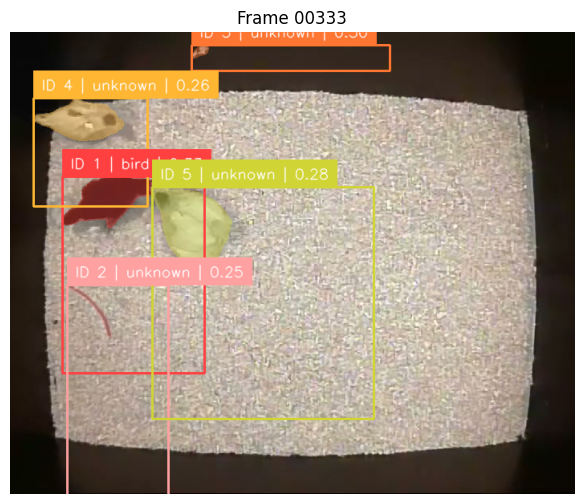

In [25]:
# Pick a random or specific frame with annotations
frame_ids = sorted(df.index.get_level_values("frame").unique().tolist())
# preview_frame = random.choice(frame_ids)  # or set e.g. 101
preview_frame = 333  # or set e.g. 101

img_path = frame_path(preview_frame)
if img_path is None:
    raise FileNotFoundError(f"No image found for frame {preview_frame} -> {preview_frame:05d}.{FRAME_EXT}")

img = cv2.imread(img_path, cv2.IMREAD_COLOR)
assert img is not None, f"Failed to read {img_path}"

df_frame = df.loc[preview_frame]  # index is object_id
dets = detections_from_frame_df(df_frame)
annotated = annotate_frame(img, dets)

# Show (RGB in matplotlib)
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title(f"Frame {preview_frame:05d}")
plt.axis("off")
plt.show()